<a href="https://colab.research.google.com/github/sw-sys/codebar_capstone_work/blob/main/Wk6_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import stats libaries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#import scikit bits

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression



In [ ]:
# import data from file in to df

df = pd.read_csv("pixels_banking_churn_capstone_dataset.csv")
df.head(10)

,customer_id,age,region,account_type,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,has_credit_card,has_crypto_wallet,uses_mobile_app,customer_service_calls,missed_payments_6m,support_rating,contract_type,monthly_fees,digital_engagement_score,churned
0,PBG-100459,25.0,North West,Premium,17,2058.0,NaN,581.0,5,No,No,Yes,3,0,NaN,Monthly,16.99,NaN,0
1,PBG-100457,27.0,London,Everyday,19,2492.0,1181.0,635.0,2,Yes,No,Yes,2,0,3.0,Annual,0.00,89.0,1
2,PBG-101022,39.0,South East,Everyday,39,3772.0,3268.0,665.0,1,Yes,No,Yes,4,0,3.0,No fixed term,0.00,96.0,0
3,PBG-100141,55.0,Northern Ireland,Plus,40,1029.0,426.0,708.0,4,Yes,No,Yes,3,0,3.0,No fixed term,7.00,100.0,0
4,PBG-100668,18.0,Scotland,Business,43,2027.0,1869.0,707.0,2,No,Yes,Yes,1,0,3.0,Annual,12.00,100.0,0
5,PBG-101011,41.0,South East,Everyday,26,1047.0,1207.0,638.0,2,Yes,No,Yes,1,1,5.0,Monthly,0.00,48.0,0
6,PBG-100151,43.0,North West,Premium,72,5970.0,8878.0,551.0,3,Yes,No,Yes,5,3,4.0,Monthly,15.00,87.0,0
7,PBG-100830,23.0,Northern Ireland,Everyday,43,1912.0,17.0,635.0,2,No,No,Yes,2,1,2.0,Monthly,0.00,70.0,1
8,PBG-100750,28.0,North West,Everyday,27,1275.0,1673.0,684.0,2,Yes,Yes,Yes,8,0,4.0,Monthly,0.00,59.0,0
9,PBG-100046,33.0,South East,Everyday,10,2615.0,1814.0,723.0,1,No,No,Yes,3,0,3.0,No fixed term,0.00,59.0,0


In [ ]:
# list the category names
list(df)

['customer_id',
 'age',
 'region',
 'account_type',
 'tenure_months',
 'monthly_income',
 'avg_monthly_balance',
 'credit_score',
 'num_products',
 'has_credit_card',
 'has_crypto_wallet',
 'uses_mobile_app',
 'customer_service_calls',
 'missed_payments_6m',
 'support_rating',
 'contract_type',
 'monthly_fees',
 'digital_engagement_score',
 'churned']

In [ ]:
df.columns

Index(['customer_id', 'age', 'region', 'account_type', 'tenure_months',
       'monthly_income', 'avg_monthly_balance', 'credit_score', 'num_products',
       'has_credit_card', 'has_crypto_wallet', 'uses_mobile_app',
       'customer_service_calls', 'missed_payments_6m', 'support_rating',
       'contract_type', 'monthly_fees', 'digital_engagement_score', 'churned'],
      dtype='object')

In [ ]:
#look at size of data
df.shape

(1200, 19)

In [ ]:
# look at the size, lay out, col names, nulls, datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1158 non-null   float64
 2   region                    1170 non-null   object 
 3   account_type              1164 non-null   object 
 4   tenure_months             1200 non-null   int64  
 5   monthly_income            1134 non-null   float64
 6   avg_monthly_balance       1140 non-null   float64
 7   credit_score              1146 non-null   float64
 8   num_products              1200 non-null   int64  
 9   has_credit_card           1200 non-null   object 
 10  has_crypto_wallet         1200 non-null   object 
 11  uses_mobile_app           1176 non-null   object 
 12  customer_service_calls    1200 non-null   int64  
 13  missed_payments_6m        1200 non-null   int64  
 14  support_

In [ ]:
# create a copy of the df

df_model_ready = df.copy()
df_model_ready.head()

,customer_id,age,region,account_type,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,has_credit_card,has_crypto_wallet,uses_mobile_app,customer_service_calls,missed_payments_6m,support_rating,contract_type,monthly_fees,digital_engagement_score,churned
0,PBG-100459,25.0,North West,Premium,17,2058.0,NaN,581.0,5,No,No,Yes,3,0,NaN,Monthly,16.99,NaN,0
1,PBG-100457,27.0,London,Everyday,19,2492.0,1181.0,635.0,2,Yes,No,Yes,2,0,3.0,Annual,0.00,89.0,1
2,PBG-101022,39.0,South East,Everyday,39,3772.0,3268.0,665.0,1,Yes,No,Yes,4,0,3.0,No fixed term,0.00,96.0,0
3,PBG-100141,55.0,Northern Ireland,Plus,40,1029.0,426.0,708.0,4,Yes,No,Yes,3,0,3.0,No fixed term,7.00,100.0,0
4,PBG-100668,18.0,Scotland,Business,43,2027.0,1869.0,707.0,2,No,Yes,Yes,1,0,3.0,Annual,12.00,100.0,0


In [ ]:
#total nulls in cols
df.isnull().sum().sum()

np.int64(426)

In [ ]:
# total nulls in cats in cols

missing_data = df_model_ready.isnull().sum()
missing_data[missing_data > 0].sort_values(ascending=False)

,0
support_rating,78
monthly_income,66
avg_monthly_balance,60
credit_score,54
age,42
digital_engagement_score,36
account_type,36
region,30
uses_mobile_app,24


In [ ]:
df.describe().loc['std']

,std
age,11.582306
tenure_months,25.575730
monthly_income,1242.752884
avg_monthly_balance,1552.214360
credit_score,75.416237
num_products,1.172950
customer_service_calls,1.598816
missed_payments_6m,0.934792
support_rating,1.126917
monthly_fees,5.898617


In [ ]:
# Find the names of all categorical and numberic features

cat_cols = df_model_ready.select_dtypes(include=['object']).columns
print("These are the categorical columns:", cat_cols)
num_cols = df_model_ready.select_dtypes(include=['int64','float64']).columns
print("these are the numeric columns:", num_cols)

These are the categorical columns: Index(['customer_id', 'region', 'account_type', 'has_credit_card',
       'has_crypto_wallet', 'uses_mobile_app', 'contract_type'],
      dtype='object')
these are the numeric columns: Index(['age', 'tenure_months', 'monthly_income', 'avg_monthly_balance',
       'credit_score', 'num_products', 'customer_service_calls',
       'missed_payments_6m', 'support_rating', 'monthly_fees',
       'digital_engagement_score', 'churned'],
      dtype='object')


In [ ]:
# correlation matrix before data cleaned

numeric_df = df_model_ready.select_dtypes(include="number")

numeric_df.corr()

,age,tenure_months,monthly_income,avg_monthly_balance,credit_score,num_products,customer_service_calls,missed_payments_6m,support_rating,monthly_fees,digital_engagement_score,churned
age,1.000000,0.043575,0.009362,0.008069,-0.065200,0.031021,-0.040690,-0.021335,0.074476,0.024179,0.051715,-0.049531
tenure_months,0.043575,1.000000,0.077866,0.060299,0.064962,-0.023714,0.003717,-0.047422,0.036611,-0.015135,-0.023979,-0.059663
monthly_income,0.009362,0.077866,1.000000,0.687533,-0.000084,-0.028098,0.006182,-0.040033,0.016122,0.025426,-0.007891,-0.033165
avg_monthly_balance,0.008069,0.060299,0.687533,1.000000,-0.003480,-0.042341,0.042188,-0.024961,0.011629,0.014414,-0.001167,0.024459
credit_score,-0.065200,0.064962,-0.000084,-0.003480,1.000000,-0.040296,0.012573,-0.038403,0.000326,0.021617,-0.018745,0.010279
num_products,0.031021,-0.023714,-0.028098,-0.042341,-0.040296,1.000000,-0.013602,0.034712,-0.014245,-0.008742,0.040037,-0.051413
customer_service_calls,-0.040690,0.003717,0.006182,0.042188,0.012573,-0.013602,1.000000,-0.018228,-0.031226,-0.003121,-0.111657,0.017336
missed_payments_6m,-0.021335,-0.047422,-0.040033,-0.024961,-0.038403,0.034712,-0.018228,1.000000,-0.050105,-0.006024,-0.003997,0.071063
support_rating,0.074476,0.036611,0.016122,0.011629,0.000326,-0.014245,-0.031226,-0.050105,1.000000,0.038583,-0.022178,-0.074395
monthly_fees,0.024179,-0.015135,0.025426,0.014414,0.021617,-0.008742,-0.003121,-0.006024,0.038583,1.000000,0.035969,-0.087442


Text(0.5, 1.0, 'Correlation Matrix')

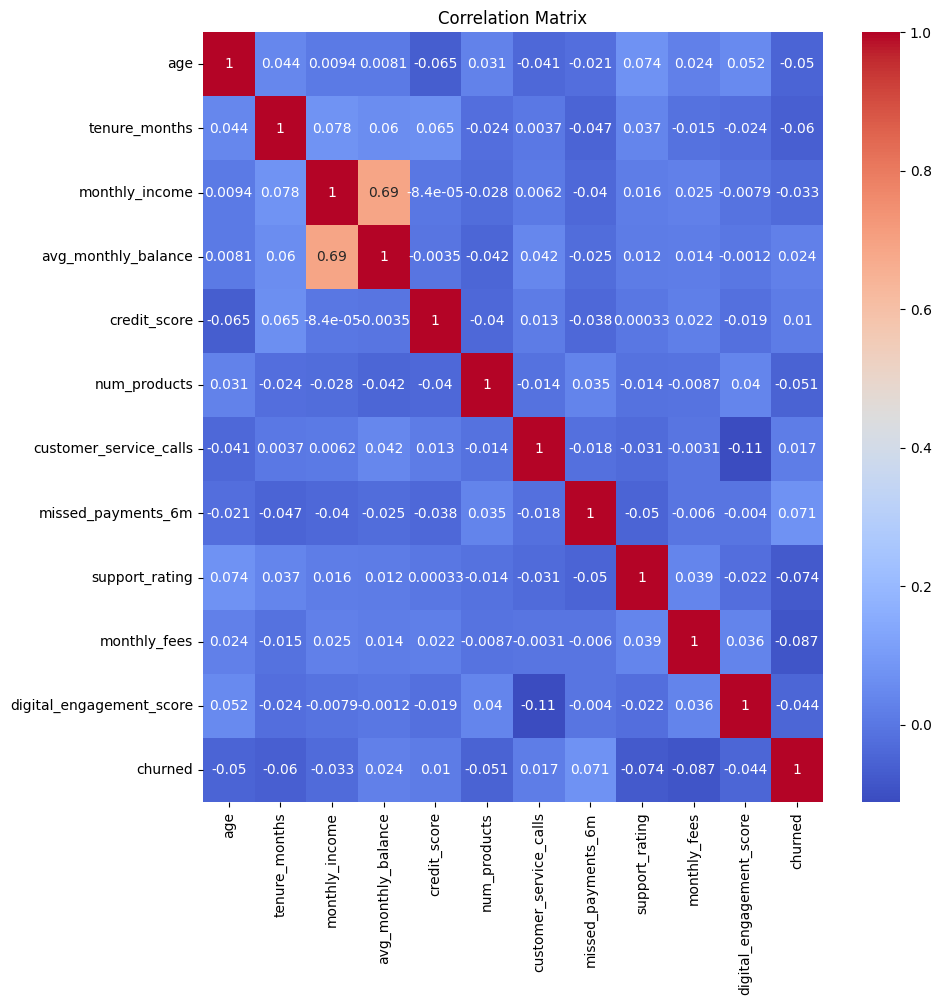

In [ ]:
# visualise correlation matrix

# plt.figure(figsize=(10,8))
# plt.imshow(numeric_df.corr())
# plt.colorbar()

corr = numeric_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

In [ ]:
# Deal with missing data

# categorical data - deal with missing values using mode

for col in cat_cols:
  mode_value = df_model_ready[col].mode()[0]
  df_model_ready[col] = df_model_ready[col].fillna(mode_value)

# chec for any missing values now

df_model_ready[cat_cols].isnull().sum()

,0
customer_id,0
region,0
account_type,0
has_credit_card,0
has_crypto_wallet,0
uses_mobile_app,0
contract_type,0


In [ ]:
# numerical data - deal with missing values using median

for col in num_cols:
  median_value = df_model_ready[col].median()
  df_model_ready[col] = df_model_ready[col].fillna(median_value)

# check for any missing values in num cols now
df_model_ready[num_cols].isnull().sum()

,0
age,0
tenure_months,0
monthly_income,0
avg_monthly_balance,0
credit_score,0
num_products,0
customer_service_calls,0
missed_payments_6m,0
support_rating,0
monthly_fees,0


Text(0.5, 1.0, 'Correlation Matrix - post data clean')

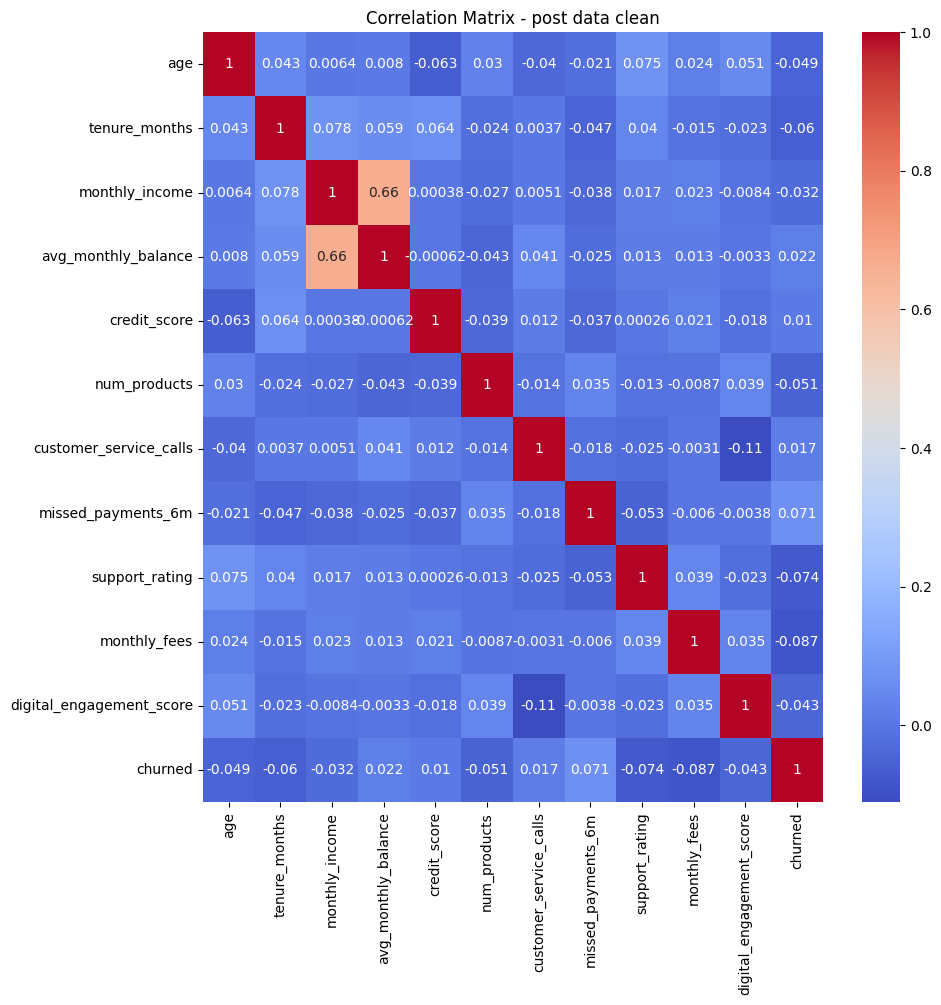

In [ ]:
# Repeat correlation matrix

corr = df_model_ready.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix - post data clean")